<a href="https://colab.research.google.com/github/AURORARISE/done-projects/blob/main/MLFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/Mydrive')

Mounted at /content/Mydrive


In [ ]:
ds = pd.read_csv("/content/Mydrive/MyDrive/MSSP6080/diabetic_data.csv")
#ds=pd.read_csv("/content/Mydrive/MyDrive/Final Project-ML/diabetic_data.csv")
ds.shape
ds.columns
print(ds['readmitted'].unique())

['NO' '>30' '<30']


In [ ]:
ds['readmitted_binary'] = np.where(ds['readmitted'] == '<30', 1, 0)
ds['readmitted_binary'].value_counts()

,count
readmitted_binary,
0,90409
1,11357


In [ ]:
db = ds[['age', 'race', 'gender', 'number_inpatient', 'number_emergency', 'number_outpatient', 'num_medications', 'number_diagnoses', 'time_in_hospital', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed']]
db.isnull().any()

,0
age,False
race,False
gender,False
number_inpatient,False
number_emergency,False
number_outpatient,False
num_medications,False
number_diagnoses,False
time_in_hospital,False
A1Cresult,True


In [ ]:
db['A1Cresult'] = db['A1Cresult'].fillna("Unknown")
db['max_glu_serum'] = db['max_glu_serum'].fillna("Unknown")
db.isnull().any()

/tmp/ipykernel_12368/2955294941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db['A1Cresult'] = db['A1Cresult'].fillna("Unknown")
/tmp/ipykernel_12368/2955294941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db['max_glu_serum'] = db['max_glu_serum'].fillna("Unknown")


,0
age,False
race,False
gender,False
number_inpatient,False
number_emergency,False
number_outpatient,False
num_medications,False
number_diagnoses,False
time_in_hospital,False
A1Cresult,False


In [ ]:
db.dtypes

,0
age,object
race,object
gender,object
number_inpatient,int64
number_emergency,int64
number_outpatient,int64
num_medications,int64
number_diagnoses,int64
time_in_hospital,int64
A1Cresult,object


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

categorical_cols = ['age', 'race', 'gender', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed']

onehotencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_array = onehotencoder.fit_transform(db[categorical_cols])
encoded_cols = onehotencoder.get_feature_names_out(categorical_cols)

encoded_db = pd.DataFrame(encoded_array, columns=encoded_cols)

In [ ]:
'''from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_db = pd.DataFrame(onehotencoder.fit_transform(db[['age','race', 'gender', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed']]))'''

"from sklearn.preprocessing import OneHotEncoder\nonehotencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)\nencoded_db = pd.DataFrame(onehotencoder.fit_transform(db[['age','race', 'gender', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed']]))"

In [ ]:
from sklearn.model_selection import train_test_split
db_num = db.drop(columns=categorical_cols)
X = pd.concat([db_num.reset_index(drop=True), encoded_db.reset_index(drop=True)], axis=1)
X.columns = X.columns.astype(str)
y = ds['readmitted_binary']
X_train, X_test, y_train, y_test = train_test_split(X, ds['readmitted_binary'], test_size=0.2, random_state=42,stratify=y)



#===========Model 1 (Baseline Regression)==================


In [ ]:
#Model 1: Baseline Regression (Logistic)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Metrics
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8884248796305394
Recall: 0.014090708938793483
ROC-AUC: 0.6386910004708705


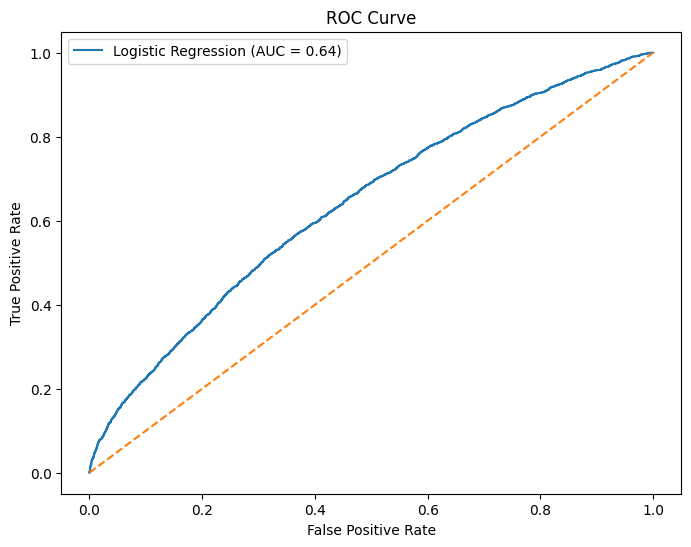

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#Check Coefficient
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df.head(10))
print(coef_df.tail(10))

                   Feature  Coefficient
0         number_inpatient     0.265175
14             age_[80-90)     0.078592
13             age_[70-80)     0.052657
4         number_diagnoses     0.041685
1         number_emergency     0.027797
5         time_in_hospital     0.022222
8              age_[20-30)     0.021554
3          num_medications     0.003581
2        number_outpatient    -0.003262
24  gender_Unknown/Invalid    -0.010726
                  Feature  Coefficient
32  max_glu_serum_Unknown    -0.281170
34             insulin_No    -0.303211
16                 race_?    -0.324616
40        diabetesMed_Yes    -0.339969
38              change_No    -0.359878
23            gender_Male    -0.386070
22          gender_Female    -0.410955
37              change_Ch    -0.447873
7             age_[10-20)    -0.457857
39         diabetesMed_No    -0.467782


In [ ]:
#Coefficient Interpretation(but remember we havn't standardization, so we cannot compare, recall is still low.So it's just insight for direction)
'''“Prior inpatient utilization was the strongest positive predictor,
suggesting that patients with frequent past hospitalizations are at higher risk of returning within 30 days.”

“Older age groups, especially patients aged 70 and above, also showed elevated readmission risk,
which aligns with expectations about frailty and chronic disease burden.”

“Indicators of clinical complexity, such as number of diagnoses and longer hospital stays,
were also associated with higher risk.”'''

'“Prior inpatient utilization was the strongest positive predictor,\nsuggesting that patients with frequent past hospitalizations are at higher risk of returning within 30 days.”\n\n“Older age groups, especially patients aged 70 and above, also showed elevated readmission risk,\nwhich aligns with expectations about frailty and chronic disease burden.”\n\n“Indicators of clinical complexity, such as number of diagnoses and longer hospital stays,\nwere also associated with higher risk.”'

In [ ]:
'''Insight：
Our baseline logistic regression shows moderate discriminative ability (AUC = 0.64),
suggesting that the model captures some meaningful patterns in readmission risk.
However, recall is very low under the default threshold, likely due to class imbalance a
nd the rarity of 30-day readmissions."·

Hence, class imbalance, and adjust threshold(might decrease 0.3) could be a way for our enhancement after meeting with prof.
Recall rate is low because class imbalance, many patients might not likely readmit within 30 days.'''

'Insight：\nOur baseline logistic regression shows moderate discriminative ability (AUC = 0.64),\nsuggesting that the model captures some meaningful patterns in readmission risk.\nHowever, recall is very low under the default threshold, likely due to class imbalance a\nnd the rarity of 30-day readmissions."·\n\nHence, class imbalance, and adjust threshold(might decrease 0.3) could be a way for our enhancement after meeting with prof.\nRecall rate is low because class imbalance, many patients might not likely readmit within 30 days.'

#===========Model 2 (Preprocessing Inprovment)==================


In [ ]:
feature_cols = [
    'age', 'race', 'gender',
    'number_inpatient', 'number_emergency', 'number_outpatient',
    'num_medications', 'number_diagnoses', 'time_in_hospital',
    'A1Cresult', 'max_glu_serum',
    'insulin', 'change', 'diabetesMed'
]

X = ds[feature_cols].copy()
y = ds['readmitted_binary']

In [ ]:
#(1)Seperate numerical and categorical variable
categorical_cols = [
    'age', 'race', 'gender',
    'A1Cresult', 'max_glu_serum',
    'insulin', 'change', 'diabetesMed'
]

numerical_cols = [
    'number_inpatient', 'number_emergency', 'number_outpatient',
    'num_medications', 'number_diagnoses', 'time_in_hospital'
]

In [ ]:
#Tran-Test Split and then preprocessing to avoid leakage
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#(2) And them Improved Missing value treatment(numerical:imputation;categorical""Missing" category)
#Answer：Missingness in laboratory-related categorical variables such as A1Cresult and max_glu_serum may reflect whether the test was not administered, rather than random data loss.
#Therefore, we treat missingness as a meaningful category rather than imputing it with a numerical summary.

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
#(3) Standardization (on training data)

In [ ]:
#Fit Model 2
model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model2.fit(X_train2, y_train2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['number_inpatient',
                                                   'number_emergency',
                                                   'number_outpatient',
                                                   'num_medications',
                                                   'number_diagnoses',
                                                   'time_in_hospital']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age', 'race', 'gender',
                                                   'A1Cresult', 'max_glu_serum',
                                                   'insulin', 'change',
                                                   'diabetesMed'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
#Model 2 Predict and Evaluation

y_pred_m2 = model2.predict(X_test2)
y_prob_m2 = model2.predict_proba(X_test2)[:, 1]

print("Model 2 - Accuracy:", accuracy_score(y_test2, y_pred_m2))
print("Model 2 - Recall:", recall_score(y_test2, y_pred_m2))
print("Model 2 - ROC-AUC:", roc_auc_score(y_test2, y_prob_m2))

Model 2 - Accuracy: 0.8884740100226
Model 2 - Recall: 0.01453104359313078
Model 2 - ROC-AUC: 0.6387229973594287


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Model 1 Baseline Logistic', 'Model 2 Improved Preprocessing Logistic'],
    'Accuracy': [0.8884248796305394, 0.8884740100226],
    'Recall': [0.014090708938793483, 0.01453104359313078],
    'ROC-AUC': [0.6386910004708705, 0.6387229973594287]
})
comparison_df

,Model,Accuracy,Recall,ROC-AUC
0,Model 1 Baseline Logistic,0.888425,0.014091,0.638691
1,Model 2 Improved Preprocessing Logistic,0.888474,0.014531,0.638723


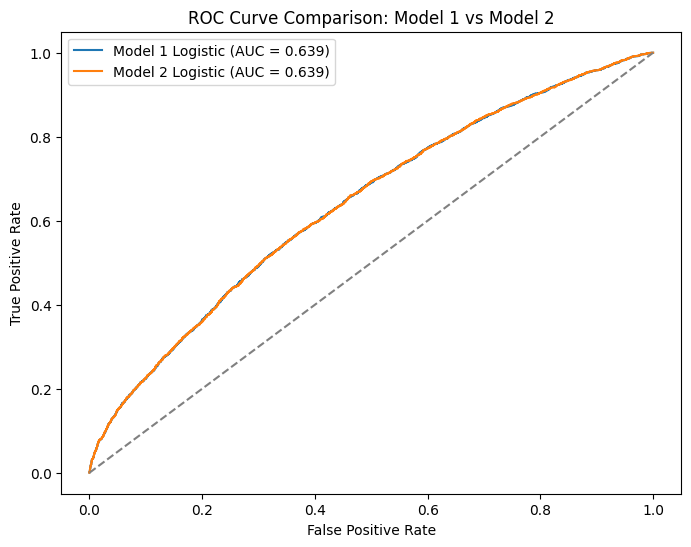

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test2, y_prob_m2)

plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label=f'Model 1 Logistic (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot(fpr2, tpr2, label=f'Model 2 Logistic (AUC = {roc_auc_score(y_test2, y_prob_m2):.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Model 1 vs Model 2")
plt.legend()
plt.show()

In [ ]:
#Insight for Model 3 and Interepretation for Model 2:
'''Compared with the baseline logistic regression, Model 2 produced slight improvements in accuracy,
recall, and ROC-AUC after introducing more principled preprocessing, including separate handling of numerical and
categorical variables, imputation, and standardization. However, the improvement was marginal, suggesting that preprocessing alone does not
solve the main limitation of the model.

The persistently low recall indicates that the major issue is likely class imbalance and
the conservative default decision threshold, rather than preprocessing quality alone.

Therefore, the next stage of the project should focus on imbalance-aware modeling strategies,
such as class weighting or threshold tuning, to improve sensitivity to high-risk patients.'''

'Compared with the baseline logistic regression, Model 2 produced slight improvements in accuracy,\nrecall, and ROC-AUC after introducing more principled preprocessing, including separate handling of numerical and\ncategorical variables, imputation, and standardization. However, the improvement was marginal, suggesting that preprocessing alone does not\nsolve the main limitation of the model.\n\nThe persistently low recall indicates that the major issue is likely class imbalance and\nthe conservative default decision threshold, rather than preprocessing quality alone.\n\nTherefore, the next stage of the project should focus on imbalance-aware modeling strategies,\nsuch as class weighting or threshold tuning, to improve sensitivity to high-risk patients.'

#=========================Model 3==================


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score
from sklearn.pipeline import Pipeline

pipeline_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

param_grid = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train2, y_train2)

print("Best parameters found:", grid_search.best_params_)
print("Best recall score from grid search:", grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test2)
y_prob_best = best_model.predict_proba(X_test2)[:, 1]

accuracy_best = accuracy_score(y_test2, y_pred_best)
recall_best = recall_score(y_test2, y_pred_best)
roc_auc_best = roc_auc_score(y_test2, y_prob_best)
precision_best = precision_score(y_test2, y_pred_best)

print("\n--- Model 3: Optimized Logistic Regression (GridSearchCV) ---")
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"ROC-AUC: {roc_auc_best:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'classifier__C': 10.0, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Best recall score from grid search: 0.48734479942215464

--- Model 3: Optimized Logistic Regression (GridSearchCV) ---
Accuracy: 0.6742
Recall: 0.5029
Precision: 0.1719
ROC-AUC: 0.6400


## Comparison of Selected Logistic Regression Models

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

comparison_df_selected = pd.DataFrame({
    'Model': [
        'Model 1 Baseline Logistic',
        'Model 2 Improved Preprocessing Logistic',
        'Model 3 Optimized Logistic (GridSearchCV)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test2, y_pred_m2),
        accuracy_best
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test2, y_pred_m2),
        recall_best
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test2, y_prob_m2),
        roc_auc_best
    ]
})

display(comparison_df_selected)

,Model,Accuracy,Recall,ROC-AUC
0,Model 1 Baseline Logistic,0.888425,0.014091,0.638691
1,Model 2 Improved Preprocessing Logistic,0.888474,0.014531,0.638723
2,Model 3 Optimized Logistic (GridSearchCV),0.674216,0.502862,0.640011


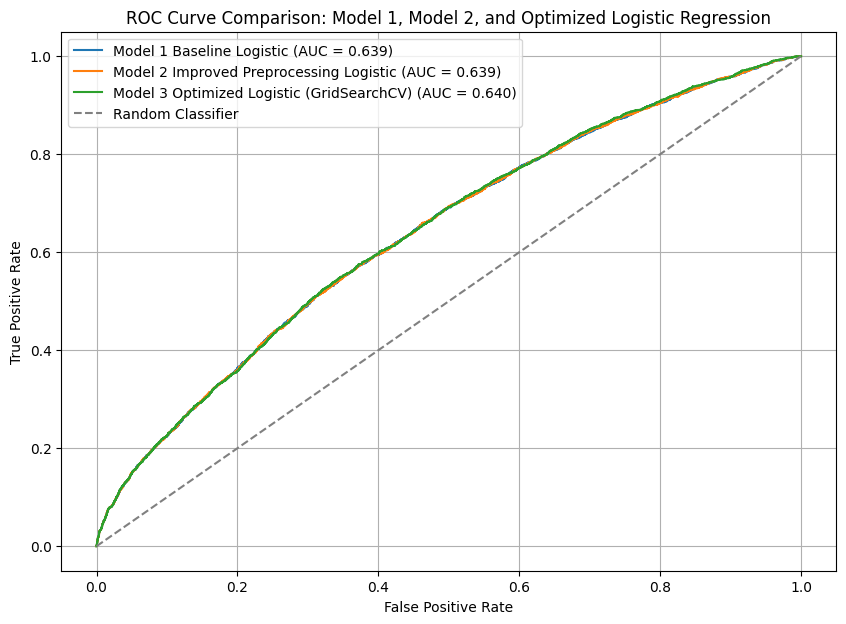

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test2, y_prob_m2)
fpr_best, tpr_best, _ = roc_curve(y_test2, y_prob_best)

plt.figure(figsize=(10, 7))
plt.plot(fpr1, tpr1, label=f'Model 1 Baseline Logistic (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot(fpr2, tpr2, label=f'Model 2 Improved Preprocessing Logistic (AUC = {roc_auc_score(y_test2, y_prob_m2):.3f})')
plt.plot(fpr_best, tpr_best, label=f'Model 3 Optimized Logistic (GridSearchCV) (AUC = {roc_auc_best:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Model 1, Model 2, and Optimized Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

#=========================Model 4==================


In [ ]:
#Model 4
#Random Forest with Parameter Adjustment
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, None],
    'classifier__class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train2, y_train2)

print("Best parameters found:", rf_grid.best_params_)
print("Best recall score from grid search:", rf_grid.best_score_)

Best parameters found: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best recall score from grid search: 0.44266036707541173


In [ ]:
#Predict and evaluate using the optimal model
best_rf = rf_grid.best_estimator_

y_pred_rf_best = best_rf.predict(X_test2)
y_prob_rf_best = best_rf.predict_proba(X_test2)[:, 1]

rf_accuracy_best = accuracy_score(y_test2, y_pred_rf_best)
rf_recall_best = recall_score(y_test2, y_pred_rf_best)
rf_auc_best = roc_auc_score(y_test2, y_prob_rf_best)
rf_precision_best = precision_score(y_test2, y_pred_rf_best)

print("\n--- Model 4: Tuned Random Forest ---")
print(f"Accuracy: {rf_accuracy_best:.4f}")
print(f"Recall: {rf_recall_best:.4f}")
print(f"Precision: {rf_precision_best:.4f}")
print(f"ROC-AUC: {rf_auc_best:.4f}")


--- Model 4: Tuned Random Forest ---
Accuracy: 0.6902
Recall: 0.4681
Precision: 0.1725
ROC-AUC: 0.6421


In [ ]:
#Compare with the previous three models together
comparison_df_all = pd.DataFrame({
    'Model': [
        'Model 1 Baseline Logistic',
        'Model 2 Improved Preprocessing Logistic',
        'Model 3 Optimized Logistic',
        'Model 4 Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test2, y_pred_m2),
        accuracy_best,
        rf_accuracy_best
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test2, y_pred_m2),
        recall_best,
        rf_recall_best
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test2, y_prob_m2),
        roc_auc_best,
        rf_auc_best
    ]
})

display(comparison_df_all)

,Model,Accuracy,Recall,ROC-AUC
0,Model 1 Baseline Logistic,0.888425,0.014091,0.638691
1,Model 2 Improved Preprocessing Logistic,0.888474,0.014531,0.638723
2,Model 3 Optimized Logistic,0.674216,0.502862,0.640011
3,Model 4 Tuned Random Forest,0.690184,0.468076,0.642123


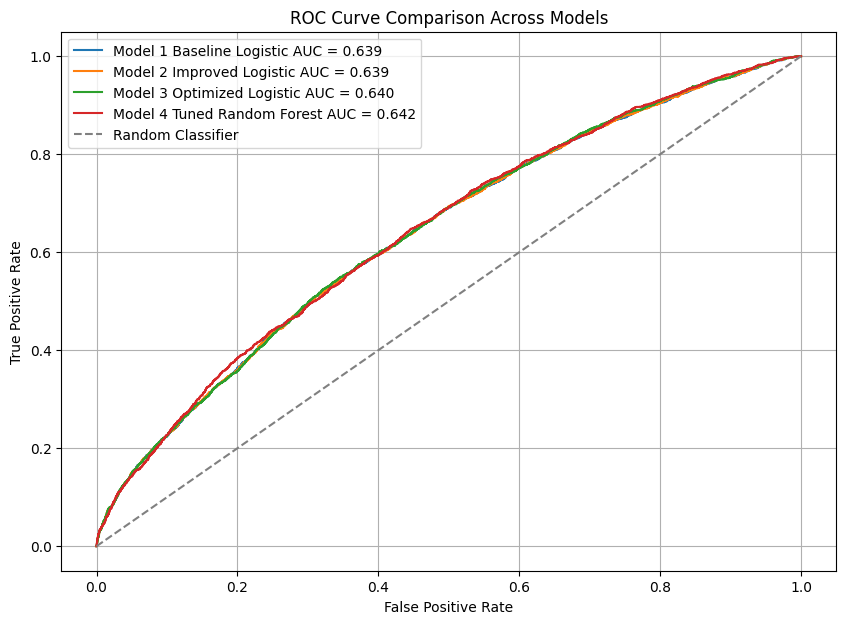

In [ ]:
#ROC curve comparison
fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test2, y_prob_m2)
fpr3, tpr3, _ = roc_curve(y_test2, y_prob_best)
fpr4, tpr4, _ = roc_curve(y_test2, y_prob_rf_best)

plt.figure(figsize=(10, 7))
plt.plot(fpr1, tpr1, label=f'Model 1 Baseline Logistic AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot(fpr2, tpr2, label=f'Model 2 Improved Logistic AUC = {roc_auc_score(y_test2, y_prob_m2):.3f}')
plt.plot(fpr3, tpr3, label=f'Model 3 Optimized Logistic AUC = {roc_auc_best:.3f}')
plt.plot(fpr4, tpr4, label=f'Model 4 Tuned Random Forest AUC = {rf_auc_best:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# get feature names after preprocessing
cat_feature_names = best_rf.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([numerical_cols, cat_feature_names])

importances = best_rf.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

display(feature_importance_df.head(15))

,Feature,Importance
0,number_inpatient,0.335798
3,num_medications,0.095327
5,time_in_hospital,0.087780
4,number_diagnoses,0.071365
1,number_emergency,0.068379
2,number_outpatient,0.038594
11,age_[50-60),0.015441
33,insulin_Down,0.014578
34,insulin_No,0.014109
23,gender_Male,0.013924


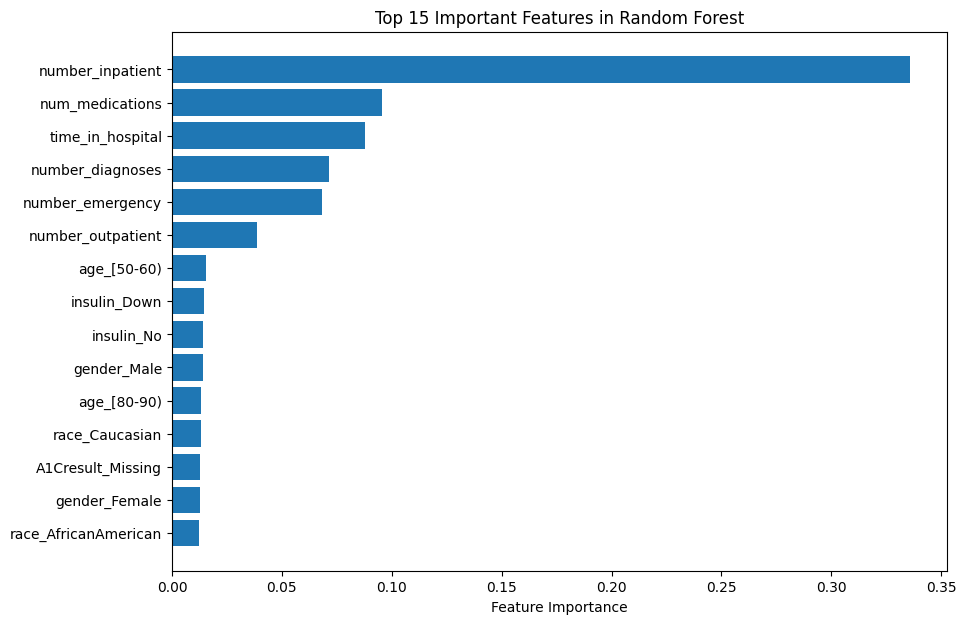

In [ ]:
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values(by='Importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features in Random Forest')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

def group_fairness_report(X_group, y_true, y_pred, group_col):
    results = []

    temp = X_group.copy()
    temp['y_true'] = y_true.values
    temp['y_pred'] = y_pred

    for g in temp[group_col].dropna().unique():
        subset = temp[temp[group_col] == g]

        if subset['y_true'].nunique() < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(subset['y_true'], subset['y_pred']).ravel()

        recall_g = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr_g = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr_g = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        results.append({
            'Group': g,
            'Count': len(subset),
            'Recall': recall_g,
            'FPR': fpr_g,
            'FNR': fnr_g
        })

    return pd.DataFrame(results).sort_values(by='Count', ascending=False)

In [ ]:
fairness_gender = group_fairness_report(X_test2.copy(), y_test2, y_pred_rf_best, 'gender')
fairness_race = group_fairness_report(X_test2.copy(), y_test2, y_pred_rf_best, 'race')
fairness_age = group_fairness_report(X_test2.copy(), y_test2, y_pred_rf_best, 'age')

print("Fairness by gender")
display(fairness_gender)

print("Fairness by race")
display(fairness_race)

print("Fairness by age")
display(fairness_age)

Fairness by gender


,Group,Count,Recall,FPR,FNR
0,Female,10924,0.473307,0.287517,0.526693
1,Male,9430,0.461614,0.275493,0.538386


Fairness by race


,Group,Count,Recall,FPR,FNR
0,Caucasian,15223,0.489225,0.301274,0.510775
1,AfricanAmerican,3866,0.430556,0.264706,0.569444
3,?,462,0.142857,0.052381,0.857143
2,Hispanic,404,0.460000,0.124294,0.540000
4,Other,276,0.300000,0.121094,0.700000
5,Asian,123,0.200000,0.203540,0.800000


Fairness by age


,Group,Count,Recall,FPR,FNR
2,[70-80),5234,0.476115,0.342814,0.523885
1,[60-70),4547,0.442344,0.271528,0.557656
3,[50-60),3457,0.438538,0.199937,0.561462
0,[80-90),3414,0.483491,0.353177,0.516509
4,[40-50),1913,0.531915,0.245217,0.468085
5,[30-40),725,0.448718,0.211747,0.551282
6,[90-100),576,0.364865,0.254980,0.635135
7,[20-30),324,0.720930,0.177936,0.279070
8,[10-20),130,0.000000,0.024194,1.000000


The results show that while the model has some predictive power, its overall performance remains limited. Although the ROC-AUC is around 0.64, indicating moderate discrimination ability, the recall is only about 0.47, meaning that more than half of high-risk patients are not identified. Additionally, the precision is very low, suggesting that many predicted high-risk cases are false positives. This indicates that the model is not sufficiently reliable for high-stakes decision-making in healthcare settings.
Comparing across models, the baseline logistic models achieve high accuracy but extremely low recall, demonstrating that accuracy alone is misleading in imbalanced datasets. The optimized logistic model and random forest improve recall substantially, but overall predictive performance remains modest.
Feature importance analysis reveals that the model primarily relies on prior healthcare utilization variables, such as number of inpatient visits, medications, and time spent in hospital. This suggests that the model captures patient health complexity rather than demographic characteristics.
However, fairness analysis shows important disparities. While performance is relatively balanced across gender, there are clear differences across racial groups, with significantly lower recall for minority populations. This is likely due to data imbalance and may lead to under-detection of high-risk patients in these groups. Similarly, performance across age groups is unstable, especially for smaller populations.
Overall, the findings suggest that while the model provides useful insights, it raises concerns about both effectiveness and equity. Improving recall and addressing fairness issues should be key priorities before deploying such models in real-world healthcare settings.